# Visualizing saved prediction-and-repair runs

Reads everything `save_run` (in `test_planted_codeword_repair.py`) wrote under `runs/`:

- the `.json` sidecars (plain Python, one per run) for an **aggregate view across all runs** - outcomes, r(v) vs rmax, timing
- one `.sobj` (Sage-native pickle) for a **deep dive into a single run** - the actual `G1`, `Q`, `Q_hat`, `v`, `w_tilde`, `w`

**Run this notebook with a SageMath kernel** (the `.sobj` cells need `sage.all.load`; if you only care about the aggregate view, a plain Python kernel with `matplotlib` works too - just skip the "deep dive" section below).

To get a SageMath kernel available in Jupyter (if you don't have one yet): `sage -n jupyter` starts Jupyter with the SageMath kernel already registered.

In [72]:
import glob
import json
import os

import matplotlib.pyplot as plt

RUNS_DIR = 'runs'

json_paths = sorted(glob.glob(os.path.join(RUNS_DIR, '*.json')))
print(f"Found {len(json_paths)} saved run(s) in {RUNS_DIR}/")

runs = []
for path in json_paths:
    with open(path) as f:
        summary = json.load(f)
    summary['_json_path'] = path
    summary['_sobj_path'] = path[:-len('.json')] + '.sobj'
    runs.append(summary)


Found 22 saved run(s) in runs/


## Aggregate view across all saved runs

Works from the `.json` summaries alone (no Sage objects needed), so this section runs fine under a plain Python kernel too.

In [73]:
# Try to use pandas for a nicer table, but don't hard-depend on it - the
# plots below only use plain lists, so they work either way.
try:
    import pandas as pd
    df = pd.DataFrame(runs)
    cols = ['n', 'k', 'q', 'alpha', 'beta', 'weight_factor', 'budgets',
            'seed', 'v_weight', 'r_v', 'rmax', 'tau', 'elapsed_s', 'outcome']
    display(df[[c for c in cols if c in df.columns]])
except ImportError:
    print("pandas not available (pip install pandas / sage -pip install pandas "
          "for a nicer table) - printing plain rows instead:\n")
    for r in runs:
        print({k: r[k] for k in ('n', 'k', 'q', 'seed', 'v_weight', 'r_v',
                                  'rmax', 'tau', 'elapsed_s', 'outcome')})

,n,k,q,alpha,beta,weight_factor,budgets,seed,v_weight,r_v,rmax,tau,elapsed_s,outcome
0,128,64,127,0.01,0.05,1.1,5,0,54,12,8,16,0.225983,correct
1,128,64,127,0.01,0.05,1.1,5,1,54,14,9,18,2.666329,failed
2,128,64,127,0.01,0.05,1.1,5,26,54,27,16,32,26.997585,failed
3,128,64,127,0.01,0.05,1.1,5,27,54,22,13,26,27.210119,failed
4,128,64,127,0.01,0.05,1.1,5,28,54,16,10,20,27.441258,failed
5,128,64,127,0.01,0.05,1.1,5,29,54,18,11,22,27.767315,failed
6,128,64,127,0.01,0.05,1.1,5,2,54,20,12,24,2.658160,failed
7,128,64,127,0.01,0.05,1.1,5,30,54,13,9,18,0.989233,correct
8,128,64,127,0.01,0.05,1.1,5,31,54,18,11,22,27.520723,failed
9,128,64,127,0.01,0.05,1.1,5,32,54,18,11,22,2.500089,correct


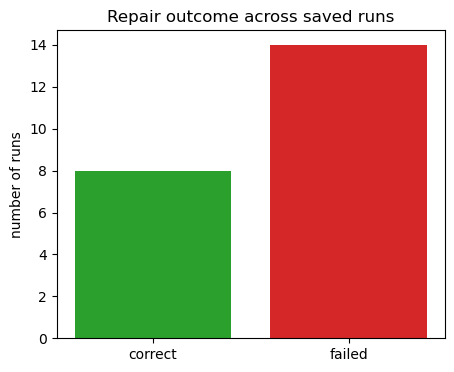

In [74]:
# Outcome counts (correct / wrong / failed)
outcome_counts = {}
for r in runs:
    outcome_counts[r['outcome']] = outcome_counts.get(r['outcome'], 0) + 1

colors = {'correct': 'tab:green', 'wrong': 'tab:orange', 'failed': 'tab:red'}

fig, ax = plt.subplots(figsize=(5, 4))
labels = list(outcome_counts.keys())
ax.bar(labels, [outcome_counts[l] for l in labels],
       color=[colors.get(l, 'tab:gray') for l in labels])
ax.set_ylabel('number of runs')
ax.set_title('Repair outcome across saved runs')
plt.show()

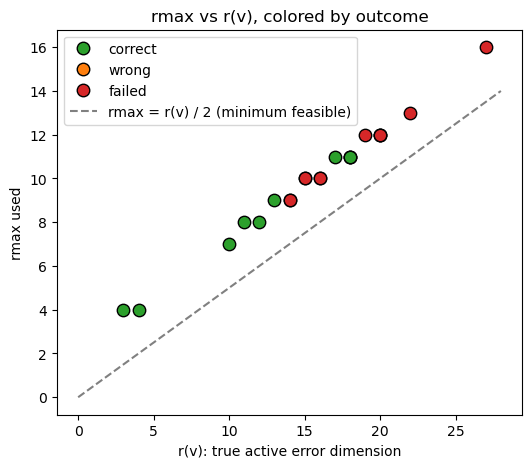

In [75]:
# r(v) vs rmax, colored by outcome. Recall the repair-feasibility
# requirement for posterior_aware_prange_repair: tau = 2*rmax must be >=
# r(v), i.e. rmax >= r(v)/2 (the dashed line below) - points below the
# line are cases where repair was mathematically doomed regardless of
# max_trials; points above it are where the radius was sufficient and
# success/failure instead reflects the search actually finding it.
fig, ax = plt.subplots(figsize=(6, 5))
for r in runs:
    ax.scatter(r['r_v'], r['rmax'], color=colors.get(r['outcome'], 'tab:gray'),
               s=80, edgecolor='black', zorder=3)

max_rv = max((r['r_v'] for r in runs), default=1)
xs = list(range(0, max_rv + 2))
ax.plot(xs, [x / 2 for x in xs], linestyle='--', color='gray',
        label='rmax = r(v) / 2 (minimum feasible)')

ax.set_xlabel('r(v): true active error dimension')
ax.set_ylabel('rmax used')
ax.set_title('rmax vs r(v), colored by outcome')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                       markeredgecolor='black', markersize=9, label=l)
           for l, c in colors.items()]
ax.legend(handles=handles + [ax.lines[-1]])
plt.show()

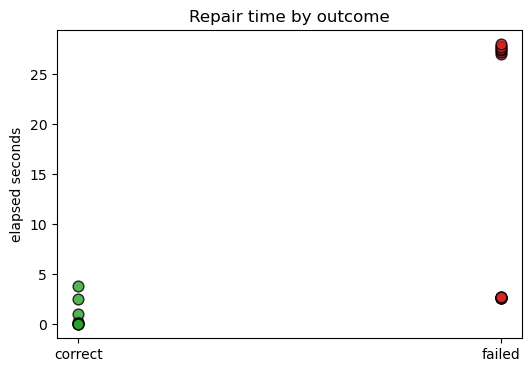

In [76]:
# Timing: how long the repair call took, by outcome
fig, ax = plt.subplots(figsize=(6, 4))
for outcome in outcome_counts:
    values = [r['elapsed_s'] for r in runs if r['outcome'] == outcome]
    ax.scatter([outcome] * len(values), values,
               color=colors.get(outcome, 'tab:gray'), s=60,
               edgecolor='black', alpha=0.8)
ax.set_ylabel('elapsed seconds')
ax.set_title('Repair time by outcome')
plt.show()

## Deep dive into one run

Loads the full `.sobj` (needs a SageMath kernel: uses `sage.all.load`) for a single run and inspects the actual objects - which rows of `Q_hat` disagree with the true `Q`, where those disagreements land relative to `v`'s support, and whether the repaired error matches the true one.

By default this picks the most recently saved run; set `RUN_ID` explicitly (the part of the filename before `.sobj`) to inspect a specific one instead.

In [77]:
from sage.all import load

RUN_ID = 'n128_k64_q127_seed35_20260813T192921'  # e.g. 'n128_k64_q127_seed20260814_20260814T153000'; None = most recent

sobj_paths = sorted(glob.glob(os.path.join(RUNS_DIR, '*.sobj')))
if not sobj_paths:
    raise FileNotFoundError(f"No .sobj files found in {RUNS_DIR}/")

chosen_path = (os.path.join(RUNS_DIR, RUN_ID + '.sobj') if RUN_ID
               else sobj_paths[-1])
print(f"Loading {chosen_path}")
data = load(chosen_path)

params = data['params']
G1, G2 = data['G1'], data['G2']
Q, Q_noisy, Q_hat = data['Q'], data['Q_noisy'], data['Q_hat']
v, w_tilde, w = data['v'], data['w_tilde'], data['w']
r_v, rmax, tau = data['r_v'], data['rmax'], data['tau']

print(params)
print(f"v weight = {v.hamming_weight()}, r(v) = {r_v}, rmax = {rmax}, tau = {tau}")
print(f"outcome = {data['outcome']}, elapsed = {data['elapsed_s']:.2f}s")

Loading runs/n128_k64_q127_seed35_20260813T192921.sobj
{'n': 128, 'k': 64, 'q': 127, 'alpha': 0.01, 'beta': 0.05, 'weight_factor': 1.1, 'budgets': 5, 'seed': 35, 'target_weight': 54}
v weight = 54, r(v) = 17, rmax = 11, tau = 22
outcome = correct, elapsed = 3.84s


### Looking at the actual matrices/vectors

`G1`/`G2`/`Q`/`Q_noisy`/`Q_hat` are 128x128-ish, and `v`/`w_tilde`/`w` are length-128 - too big to just `print()` usefully. `show_matrix`/`show_vector` below print a truncated, labeled corner/prefix (with the true shape and, for vectors, the Hamming weight and support), and `show_matrix_heatmap` renders a whole matrix at once as an image, which is the more useful view at this size.

G1: 64 x 128 matrix over Finite Field of size 127
[ 97   0  63   0   0   0  54   1 126   0   0   0   0   0   0  50]
[  7  19  33  28 103 108 124 112  19  91  23  52  89 124 117  61]
[ 94  98  84  23  97  95 112  87  70  58  85  56  61  13  83 105]
[100  57   8  51 121   0 122  38  84  81  74  61  32  46   1  49]
[ 82  40  61  39  84  52 114  77  67  22  15  26  11  33  86  75]
[ 62   2  82  34  68  58  72 103  90 101  73  15  62 100  73  87]
[ 95  46   3 102 122  26  57 102  49  47  96  72 122 107 117  36]
[  0  26  20  77  94 114  79  52  93  31  49  26  73  39 118 122]
[ 38 126  35  74   0  64   4  88  33 126  17  49  14  10  61 113]
[ 71  92 112  10  81  55  40  21 114  15  43  29  69  68  91   3]
[105  41 123  20  45  27 126 120  20  49  54  26  48  54  84  12]
[ 67  40  46  42  54   1  91  44  68 108  38  93 104   5  53 107]
[106  70 104  86  44  96   9  72  83 122  43  96  50 101  10  12]
[ 53  70  29   5  20  71  18 100  28  45  77  35  67  42  49  28]
[ 62  21  72  26  26 106 1

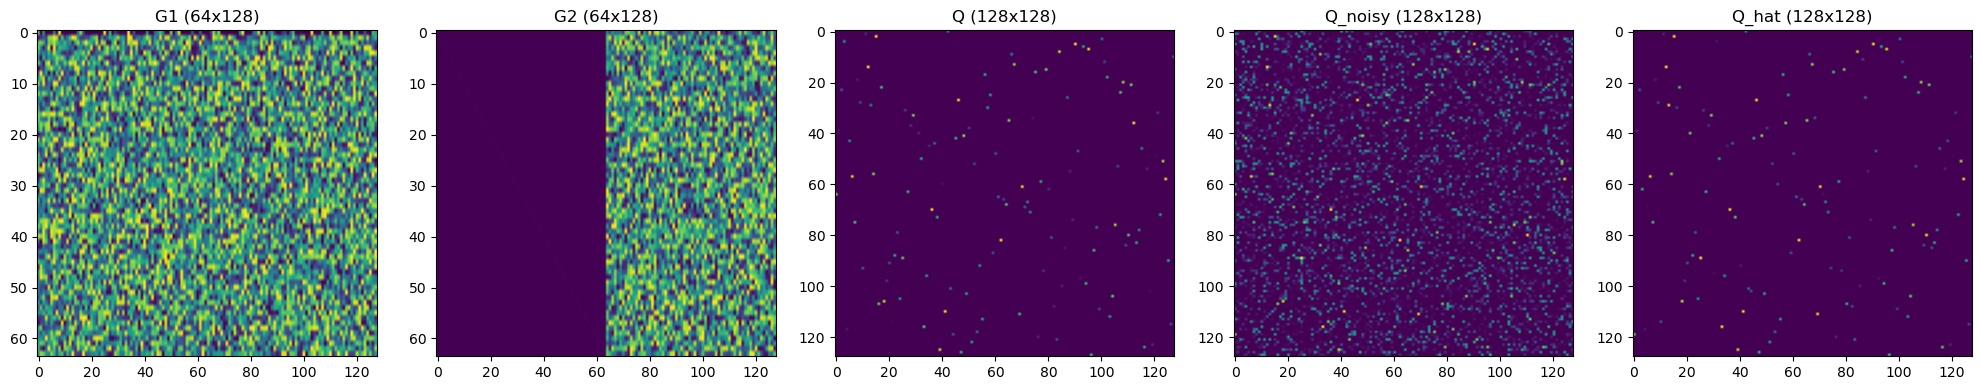

In [78]:
import numpy as np


def show_matrix(M, name, max_rows=12, max_cols=12):
    """
    Prints a truncated, readable view of a (possibly large) Sage matrix:
    the top-left max_rows x max_cols corner, with the true shape noted so
    it is clear when the printout has been cut off.
    """
    nrows, ncols = M.nrows(), M.ncols()
    print(f"{name}: {nrows} x {ncols} matrix over {M.base_ring()}")
    r, c = min(nrows, max_rows), min(ncols, max_cols)
    print(M.submatrix(0, 0, r, c))
    if r < nrows or c < ncols:
        print(f"  ... showing top-left {r}x{c} corner of {nrows}x{ncols} "
              f"(pass max_rows/max_cols to show_matrix to see more)")
    print()


def show_vector(v, name, max_entries=30):
    """
    Prints a truncated, readable view of a (possibly long) Sage vector,
    together with its Hamming weight and support (nonzero positions).
    """
    n = len(v)
    print(f"{name}: length-{n} vector over {v.base_ring()}, "
          f"weight = {v.hamming_weight()}")
    shown = min(n, max_entries)
    print(list(v[:shown]))
    if shown < n:
        print(f"  ... showing first {shown}/{n} entries")
    support = [i for i in range(n) if v[i] != 0]
    trailer = ' ...' if len(support) > max_entries else ''
    print(f"  support (nonzero positions): {support[:max_entries]}{trailer}")
    print()


def show_matrix_heatmap(M, name, ax=None):
    """
    Renders a whole matrix at once as an image (entry value -> color),
    which scales much better than printing text once the matrix is
    bigger than a handful of rows/columns.
    """
    arr = np.array([[int(x) for x in row] for row in M.rows()], dtype=float)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(arr, cmap='viridis', aspect='auto')
    ax.set_title(f"{name} ({M.nrows()}x{M.ncols()})")
    if own_fig:
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.show()
    return im


def show_run_objects(data, max_rows=16, max_cols=16, max_entries=30):
    """
    Prints a truncated, readable view of every matrix/vector saved for
    one run (G1, G2, Q, Q_noisy, Q_hat, v, w_tilde, w), followed by
    side-by-side heatmaps of the matrices.
    """
    for name in ('G1', 'G2', 'Q', 'Q_noisy', 'Q_hat'):
        show_matrix(data[name], name, max_rows=max_rows, max_cols=max_cols)
    for name in ('v', 'w_tilde'):
        show_vector(data[name], name, max_entries=max_entries)
    if data['w'] is not None:
        show_vector(data['w'], 'w', max_entries=max_entries)
    else:
        print("w: repair FAILED, no repaired word to show\n")

    matrix_names = ['G1', 'G2', 'Q', 'Q_noisy', 'Q_hat']
    fig, axes = plt.subplots(1, len(matrix_names), figsize=(4 * len(matrix_names), 4))
    for ax, name in zip(axes, matrix_names):
        show_matrix_heatmap(data[name], name, ax=ax)
    plt.tight_layout()
    plt.show()


show_run_objects(data)

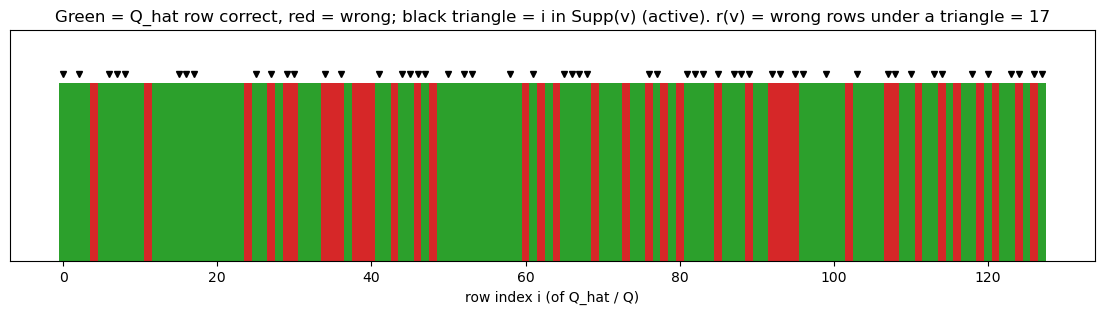

In [79]:
# Which rows of Q_hat are correct, and where they sit relative to v's
# active support (Supp(v)) - r(v) is exactly the count of red bars that
# also have a marker on them.
n = params['n']
row_correct = [list(Q_hat[i]) == list(Q[i]) for i in range(n)]
active_support = set(i for i in range(n) if v[i] != 0)

fig, ax = plt.subplots(figsize=(14, 3))
bar_colors = ['tab:green' if c else 'tab:red' for c in row_correct]
ax.bar(range(n), [1] * n, color=bar_colors, width=1.0)
for i in active_support:
    ax.plot(i, 1.05, marker='v', color='black', markersize=5)
ax.set_ylim(0, 1.3)
ax.set_yticks([])
ax.set_xlabel('row index i (of Q_hat / Q)')
ax.set_title(
    'Green = Q_hat row correct, red = wrong; black triangle = i in Supp(v) '
    f'(active). r(v) = wrong rows under a triangle = {r_v}'
)
plt.show()

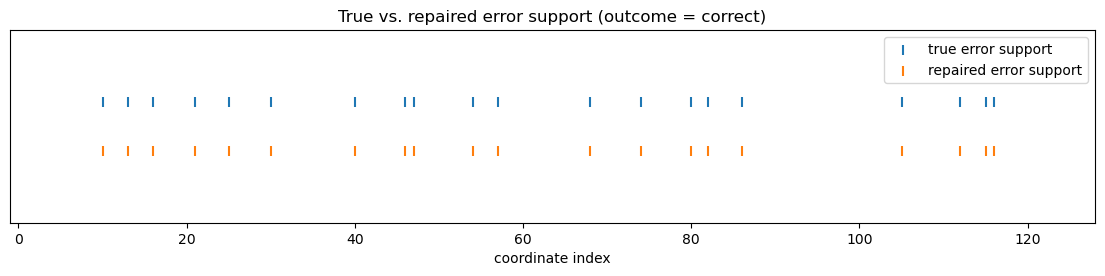

In [80]:
# Compare the *true* prediction error (w_tilde - v*Q) against what the
# repair actually found and subtracted (w_tilde - w, if repair returned
# something). If outcome == 'correct' these should be identical; if
# 'wrong', the repair found *a* syndrome-and-weight-consistent error at
# the right radius that happens not to be the true one; if 'failed',
# there is no repaired error to compare.
true_error = w_tilde - v * Q
true_error_support = [i for i in range(n) if true_error[i] != 0]

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.scatter(true_error_support, [1] * len(true_error_support),
           color='tab:blue', label='true error support', s=60, marker='|')

if w is not None:
    repaired_error = w_tilde - w
    repaired_error_support = [i for i in range(n) if repaired_error[i] != 0]
    ax.scatter(repaired_error_support, [0.8] * len(repaired_error_support),
               color='tab:orange', label='repaired error support', s=60, marker='|')
else:
    ax.text(n / 2, 0.8, 'repair FAILED - no repaired error to show',
            ha='center', color='tab:red')

ax.set_xlim(-1, n)
ax.set_ylim(0.5, 1.3)
ax.set_yticks([])
ax.set_xlabel('coordinate index')
ax.set_title(f'True vs. repaired error support (outcome = {data["outcome"]})')
ax.legend(loc='upper right')
plt.show()

In [81]:
from sage.all import GF

F = GF(127)
G1, G2, Q = data['G1'], data['G2'], data['Q']
v, w, w_tilde = data['v'], data['w'], data['w_tilde']
n, k = data['params']['n'], data['params']['k']

# 0. Rank sanity check: G1 and G2 must both have full row rank k for the
# code they generate to actually have dimension k (a rank-deficient G
# would silently generate a *smaller* code than intended, and everything
# downstream - parity-check matrix, GV bound, etc. - would be wrong).
print("rank(G1) == k?                 ", G1.rank() == k, f"(rank={G1.rank()}, k={k})")
print("rank(G2) == k?                 ", G2.rank() == k, f"(rank={G2.rank()}, k={k})")

# 1. v is a genuine codeword of C = rowspace(G1)
H1 = G1.right_kernel().matrix()
print("v in C  (H1 * v == 0)?         ", (H1 * v).is_zero())

# 2. w is a genuine codeword of C' = rowspace(G2)
H2 = G2.right_kernel().matrix()
print("w in C' (H2 * w == 0)?         ", (H2 * w).is_zero())

# 3. Monomial maps preserve Hamming weight - a necessary condition
print("wt(v) == wt(w)?                ",
      v.hamming_weight() == w.hamming_weight(),
      f"({v.hamming_weight()} vs {w.hamming_weight()})")

# 4. The actual equivalence claim: w should be *exactly* v * Q (the true secret)
predicted = v * Q
print("w == v * Q  (true equivalence)?", w == predicted)

if w != predicted:
    diff_positions = [i for i in range(len(w)) if w[i] != predicted[i]]
    print("  mismatched coordinates:", diff_positions)
    print("  v*Q  at those coords:  ", [predicted[i] for i in diff_positions])
    print("  w    at those coords:  ", [w[i] for i in diff_positions])

# 5. For contrast: w_tilde is the *unrepaired* prediction (v * Q_hat, using
# the approximate secret) - it generally will NOT equal v*Q. That gap is
# exactly what the repair step is supposed to close.
print("\nw_tilde == v * Q (before repair)?", w_tilde == predicted)
if w_tilde != predicted:
    diff = [i for i in range(len(w_tilde)) if w_tilde[i] != predicted[i]]
    print("  w_tilde disagrees with v*Q at:", diff, "-> these are exactly the active-and-wrong Q_hat rows")

rank(G1) == k?                  True (rank=64, k=64)
rank(G2) == k?                  True (rank=64, k=64)
v in C  (H1 * v == 0)?          True
w in C' (H2 * w == 0)?          True
wt(v) == wt(w)?                 True (54 vs 54)
w == v * Q  (true equivalence)? True

w_tilde == v * Q (before repair)? False
  w_tilde disagrees with v*Q at: [10, 13, 16, 21, 25, 30, 40, 46, 47, 54, 57, 68, 74, 80, 82, 86, 105, 112, 115, 116] -> these are exactly the active-and-wrong Q_hat rows
